# <font color='blue'>FUMEC - Analytics com Python</font>
## **Trabalho Autoinstrucional**

<br>**ATENÇÃO:** para salvar o arquivo .ipynb do notebook, faça da seguinte forma:

* **Google Colaboratory**: opção do menu "Arquivo --> Fazer download --> Fazer o download do .ipynb"

* Salve o arquivo com o nome "**SeuNome_AI.ipynb**"

<br>


# **Orientações**

## Objetivo
Pesquisar cases (estudos de casos, exemplos) na web de soluções de analytics e machine  learning em python, ilustrando problemas de classificação, regressão, associação, dentre outros.

## Atividades

* Pesquisar soluções de analytics, machine learning, automated machine learning, deep learning disponíveis em python que usem as bibliotecas numpy, pandas, scikit-learn, tensorflow, seaborn, matplotlib etc.


## <font color='red'>Importante</font>

* Pesquisar soluções de analytics, machine learning, automated machine learning, deep learning disponíveis em python que usem as bibliotecas numpy, pandas, scikit-learn, tensorflow, seaborn, matplotlib etc.

* Transcrever e documentar a solução encontrada em notebook do Google Colab para ser entregue

* Importante: o notebook a ser apresentado deve estar funcional, isto é, deve rodar para que eu consiga rodar os exemplos



# **Trabalho**

O seguinte trabalho consistem em mostrar uma solução de machine learning para ***remoção de ruídos em imagens a partir de aprendizado de dicionário***. Foi feita uma pesquisa a partir de um documento encontrado no sickit-learn, neste notebook haverá explicações sobre os conceitos trabalhados, como os conceitos se aplicam na solução, todo o código da solução e imagens para ilustrar o tratamento da imagem. O algoritmo foi escolhido pois é muito útil para diversas áreas, inclusive fora da computação, como design e biologia.

## Objetivo

Demostrar a remoção de ruídos de uma imagem a partir da solução gerada em python.

Fonte:

https://scikit-learn.org/stable/auto_examples/decomposition/plot_image_denoising.html

## Desenvolvimento do trabalho

Importar as bibliotecas a serem utilizadas

In [ ]:
# numpy utilizada para os cálculos
# e face utilizada para trazer a imagem
import numpy as np
from scipy.datasets import face

# matplotlib e pyplot utilizadas para visualização dos erros
import matplotlib.pyplot as plt

# time utilizada para calcular o tempo da extração de patches
from time import time

# extract_patches_2d e image utilizada para extração de patches
from sklearn.feature_extraction.image import extract_patches_2d

# minibatchdictionarylearning utilizada para aprendizado de
# um conjunto de padrões
from sklearn.decomposition import MiniBatchDictionaryLearning

# reconstruct_from_patches_2d utilizada para reconstrução da imagem
from sklearn.feature_extraction.image import reconstruct_from_patches_2d

## Primeiros conceitos

### Explicação simplificada do processo

A reconstrução da imagem é feita em partes. Primeiro, do lado esquerdo, teremos a metade da imagem original usada para o treinamento e a partir dessa metade o lado direito será reconstruído. Como o documento original aponta, utilizar uma imagem sem ruídos traria um melhor resultado, mas a ideia é reconstruir sem a disponibilidade da imagem original, apenas a imagem ruidosa. Para avaliar a qualidade da reconstrução é recomendado ver a imagem original e a imagem retornada pelo algoritmo. Se o resultado for perfeito, ele se parece com o ruído gaussiano.

<br>

### Carregamento da imagem

As primeiras linhas da solução, como os comentários do próprio código apontam, após a importação da numpy, a função face é importada, para trazer a imagem de um guaxinim como exemplo a ser utilizado. Após trazer a imagem, os pixels da imagem representados pela variável `raccoon_face` são convertidos do formato uint8, que variam de 0 a 255, para ponto flutuante (float), com valores entre 0 e 1, para evitar erros numéricos. Em seguida um fatiamento ocorre na imagem, pegando fatias de pixels em diferentes configurações, depois soma tudo e divide por 4. Na prática o que está sendo feito é uma redução da imagem em 4 vezes, sem que a imagem perda qualidade, depois a altura e a largura são salvas. Por fim, a distorção começa, uma cópia da imagem é gerada, dessa imagem a metade é pega e nela o ruído é aplicado com a função `np.random.randn`, tendo a intensidade controlada pela constante 0.075.



In [ ]:
raccoon_face = face(gray=True)

# Convert from uint8 representation with values between 0 and 255 to
# a floating point representation with values between 0 and 1.
raccoon_face = raccoon_face / 255.0

# downsample for higher speed
raccoon_face = (
    raccoon_face[::4, ::4]
    + raccoon_face[1::4, ::4]
    + raccoon_face[::4, 1::4]
    + raccoon_face[1::4, 1::4]
)
raccoon_face /= 4.0
height, width = raccoon_face.shape

# Distort the right half of the image
print("Distorting image...")
distorted = raccoon_face.copy()
distorted[:, width // 2 :] += 0.075 * np.random.randn(height, width // 2)

Distorting image...


### Exibição da imagem distorcida

A função que inicia a exibição, `show_with_diff`, recebe a imagem que quer ser demonstrada, a imagem original e o título do gráfico. Dentro da função, uma janela de plot é criada, uma divisão na janela é feita e a função `imshow` é chamada, para exibir a imagem como ela por meio dos parâmetros, os números dos eixos também são removidos para que a imagem fique mais limpa.

<br>

Depois o erro é calculado, se o valor for próximo de 0 está igual ao original, se for um valor alto, então há um erro grande. Com isso, é calculada a norma de Frobenius da diferença entre as imagens, representando o erro total de reconstrução, se o número for pequeno é uma imagem boa, se não, é um imagem ruim, essa diferença é mostrada no título do plot. Neste plot, o erro pixel a pixel é mostrado com PuOr, uma colormap de roxo e laranja, o roxo representa um erro negativo e o laranja um erro positivo, se for cinza ou branco quase não há erros. A remoção dos eixos para limpeza visual também ocorre aqui. No fim, alguns ajustes visuais são feitos e a função é chamada exibindo a imagem. No fim a ideia não é apenas mostrar a imagem, mas mostrar o quão errada ela está, o que facilita na visualização do funcionamento da solução

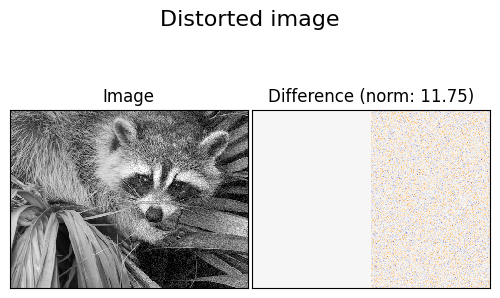

In [ ]:
def show_with_diff(image, reference, title):
    """Helper function to display denoising"""
    plt.figure(figsize=(5, 3.3))
    plt.subplot(1, 2, 1)
    plt.title("Image")
    plt.imshow(image, vmin=0, vmax=1, cmap=plt.cm.gray, interpolation="nearest")
    plt.xticks(())
    plt.yticks(())
    plt.subplot(1, 2, 2)
    difference = image - reference

    plt.title("Difference (norm: %.2f)" % np.sqrt(np.sum(difference**2)))
    plt.imshow(
        difference, vmin=-0.5, vmax=0.5, cmap=plt.cm.PuOr, interpolation="nearest"
    )
    plt.xticks(())
    plt.yticks(())
    plt.suptitle(title, size=16)
    plt.subplots_adjust(0.02, 0.02, 0.98, 0.79, 0.02, 0.2)


show_with_diff(distorted, raccoon_face, "Distorted image")

### Extração dos patches de referência

Primeiramente, faz-se necessário entender o que são os patches e para que eles servem nesse caso.

<br>

#### Patches
Patches são os pequenos pedaços da imagem, neste código, de tamanho 7x7. Estes pedaços servem para o algoritmo aprender os pequenos pedaços, pois é mais simples aprender pequenas partes locais do que deixar o código aprender a imagem inteira, aplicando o conceito de dividir para conquistar.

<br>

Voltando ao código, temos uma variável para salvar o tempo inicial e a definição do tamanho dos patches, como citado anteriormente sendo 7x7. Na próxima linha, a função `extract_patches_2d`, pega a metade esquerda para treinar e retorna um array com os patches. Em seguida um reshape é feito para transformar o array em um vetor, pois os algoritmos de machine learning trabalham com vetores. Por fim temos a centralização dos dados subtraindo a média de cada coluna e a normalização pelo desvio padrão, que é feita para evitar que alguns pixels dominem o aprendizado deixando o modelo mais estável. Um print encerrando o código mostra quantos patches foram extraídos e quanto tempo demorou.

In [ ]:
# Extract all reference patches from the left half of the image
print("Extracting reference patches...")
t0 = time()
patch_size = (7, 7)
data = extract_patches_2d(distorted[:, : width // 2], patch_size)
data = data.reshape(data.shape[0], -1)
data -= np.mean(data, axis=0)
data /= np.std(data, axis=0)
print(f"{data.shape[0]} patches extracted in %.2fs." % (time() - t0))

Extracting reference patches...
22692 patches extracted in 0.02s.


### Aprendendo o dicionário a partir de patches de referência

As primeiras linhas declaram uma variável que armazena o tempo inicial. Após isso, o algoritmo de dicionário começa a ser configurado com os seguintes parâmetros: `n_components=50` quantidade de padrões (átomos) aprendidos pelo modelo, `batch_size=200` número de patches usados por vez (aqui blocos menores são utilizados e os dados não são lidos todos de uma vez, ocorre o chamado mini_batch), `alpha=1.0` controlando a esparsidade e `max_iter=10` número máximo de iterações ou quantas vezes o dicionário é ajustado pelo modelo. Na linha seguida a função `fit(data)` analisa os patches e aprende seus padrões para que `.components_` retorne o dicionário aprendido. Um print é feito antes da exibição do dicionário para mostrar quanto tempo e quantas iterações foram feitas. Por fim, uma imagem é plotada para apresentar o dicionário e com o auxílio de um laço *for* todos os padrões são percorridos e montados na tela de forma similar as imagens montadas anteriormente, com a retirada dos eixos para maior clareza e outros parâmetros específicos.

Learning the dictionary...
1.0 iterations / 109 steps in 27.18.


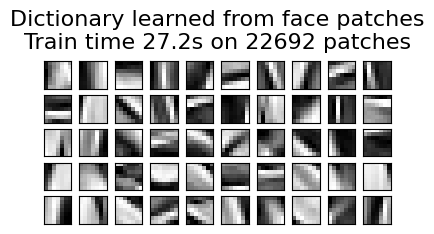

In [ ]:
print("Learning the dictionary...")
t0 = time()
dico = MiniBatchDictionaryLearning(
    # increase to 300 for higher quality results at the cost of slower
    # training times.
    n_components=50,
    batch_size=200,
    alpha=1.0,
    max_iter=10,
)
V = dico.fit(data).components_
dt = time() - t0
print(f"{dico.n_iter_} iterations / {dico.n_steps_} steps in {dt:.2f}.")

plt.figure(figsize=(4.2, 4))
for i, comp in enumerate(V[:100]):
    plt.subplot(10, 10, i + 1)
    plt.imshow(comp.reshape(patch_size), cmap=plt.cm.gray_r, interpolation="nearest")
    plt.xticks(())
    plt.yticks(())
plt.suptitle(
    "Dictionary learned from face patches\n"
    + "Train time %.1fs on %d patches" % (dt, len(data)),
    fontsize=16,
)
plt.subplots_adjust(0.08, 0.02, 0.92, 0.85, 0.08, 0.23)


### Extração dos trechos ruidosos e reconstrução usando o dicionário

Para entrarmos no último bloco de código é interessante ter o entendimento dos métodos utilizados pelo algoritmo para fazer as combinações dos patches:

<br>

#### OMP - Orthogonal Matching Pursuit
Algoritmo do tipo guloso(greedy) e iterativo que tem como objetivo encontrar a solução mais aproximada e esparsa do patch, selecionando iterativamente os átomos que melhor explicam o resíduo. Este algoritmo é considerado rápido e fácil de entender, além de funcionar bem com a solução proposta.

<br>

#### LARS - Least Angle Regression
O método LARS é considerado o mais matemático e menos intuitivo, resolvendo um problema de otimização tentando equilibrar erros baixos e poucos coeficientes. Resolve de forma global, diferente do OMP, o que pode resultar em imagens mais borradas.

<br>

#### Thresholding
O mais simples dos citados, esse algoritmo aplica um limiar (alpha) e zera coeficientes abaixo desse valor, mantendo apenas os coeficientes mais significativos. Isso reduz a complexidade computacional, resultando em maior velocidade porém gera um resultado pior visto que nem sempre coeficientes pequenos podem ser ignorados ou coeficientes grandes podem ser apenas ruídos desnecessários.

<br>

Com os conceitos em mente podemos ler o fim do código e apresentar os resultados. Nas primeiras linhas uma variável é utilizada para cronometrar a reconstrução seguida da chamada da função `extract_patches_2d`, citada anteriormente, pegando a metade ruidosa da imagem (direita) e a transformando em um vetor com o reshape. Depois a média dos patches é calculada e subtraída, para realizar o mesmo processo de centralização de dados que citamos na extração dos patches de referência. Em sequência, uma lista com os detalhes dos algoritmos é criada e o dicionário, chamado de `reconstructions`, é declarado para guardar as imagens reconstruídas. Com auxílio novamente de um loop *for*, um processo completo é rodado para cada método da lista detalhada criada antes, começando com a imagem original para que depois a parte com ruído seja substituída. Novamente, o tempo é calculado para cada algoritmo, as configurações relacionadas ao esparso são feitas e a execução do esparso em si (encontrar o coeficiente α, ou seja, quais padrões e quanto usar) também ocorre. Seguidamente os patches são recriados sem ruídos, a descentralização é feita e o formato da imagem é restaurado. Há um *if* específico para a resolução com Thresholding, pois o mesmo pode gerar valores estranhos. Por fim, a imagem é plotada e podemos comparar a imagem original (esquerda) com a reconstrução (direita).

Extracting noisy patches... 
done in 0.01s.
Orthogonal Matching Pursuit
1 atom...
done in 2.27s.
Orthogonal Matching Pursuit
2 atoms...
done in 6.91s.
Least-angle regression
4 atoms...
done in 16.69s.
Thresholding
 alpha=0.1...
done in 0.20s.


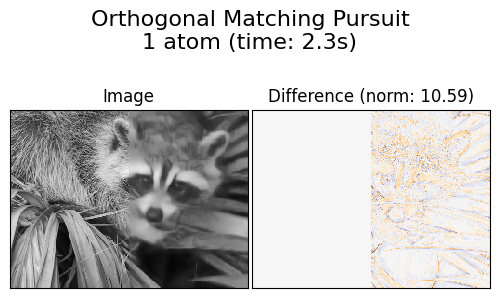

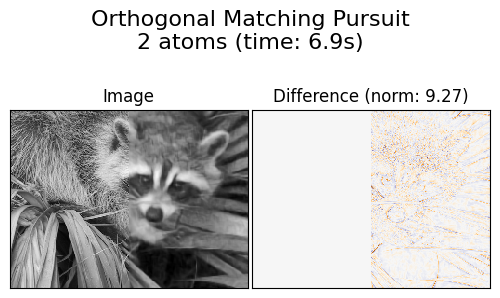

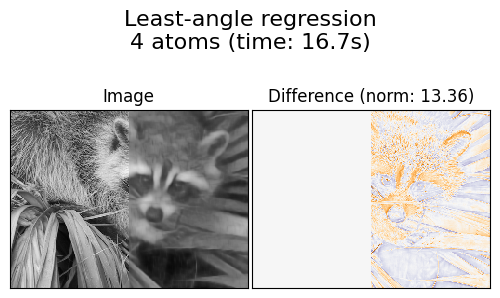

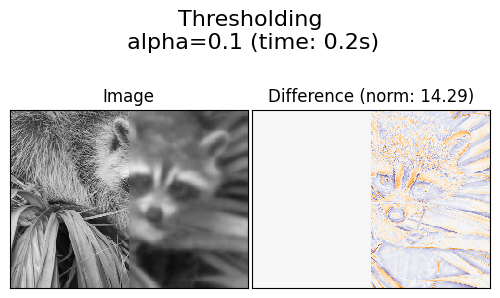

In [ ]:
from sklearn.feature_extraction.image import reconstruct_from_patches_2d

print("Extracting noisy patches... ")
t0 = time()
data = extract_patches_2d(distorted[:, width // 2 :], patch_size)
data = data.reshape(data.shape[0], -1)
intercept = np.mean(data, axis=0)
data -= intercept
print("done in %.2fs." % (time() - t0))

transform_algorithms = [
    ("Orthogonal Matching Pursuit\n1 atom", "omp", {"transform_n_nonzero_coefs": 1}),
    ("Orthogonal Matching Pursuit\n2 atoms", "omp", {"transform_n_nonzero_coefs": 2}),
    ("Least-angle regression\n4 atoms", "lars", {"transform_n_nonzero_coefs": 4}),
    ("Thresholding\n alpha=0.1", "threshold", {"transform_alpha": 0.1}),
]

reconstructions = {}
for title, transform_algorithm, kwargs in transform_algorithms:
    print(title + "...")
    reconstructions[title] = raccoon_face.copy()
    t0 = time()
    dico.set_params(transform_algorithm=transform_algorithm, **kwargs)
    code = dico.transform(data)
    patches = np.dot(code, V)

    patches += intercept
    patches = patches.reshape(len(data), *patch_size)
    if transform_algorithm == "threshold":
        patches -= patches.min()
        patches /= patches.max()
    reconstructions[title][:, width // 2 :] = reconstruct_from_patches_2d(
        patches, (height, width // 2)
    )
    dt = time() - t0
    print("done in %.2fs." % dt)
    show_with_diff(reconstructions[title], raccoon_face, title + " (time: %.1fs)" % dt)

plt.show()


### Exemplos de Uso

Como comentado no início deste notebook, o algoritmo se mostra bem útil para o que propõe a fazer por si só, entretanto há muitas aplicações fora da computação que são interessante e válidas de serem comentadas, já que elas foram um dos pontos principais para a escolha deste algoritmo.

A área de tratamento de imagem sem dúvida se beneficia bastante desses algoritmos, pois eles permitem mais compressões e reconhecimento facilitado de objetos e faces em imagens, tornando os arquivos menores e melhores.

Outro área interessante de se citar é a área da biologia e/ou saúde. Raios-X, ultrassons, ressonâncias magnéticas, tomografias computadorizadas e PET scans. Os algoritmos de remoção de ruído ajudam a mostrar detalhes que podem ser críticos para análises de microorganismos e tecidos. Abaixo vemos uma imagem de uma aplicação da remoção de ruído feita para imagens de um microscópio:

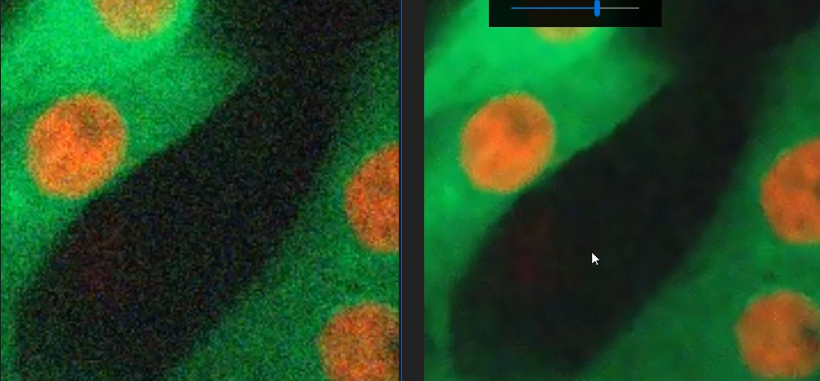

Vídeo completo que mostra o processo: https://www.youtube.com/watch?v=2PrzKWkqOtU

### Conclusão

O trabalho trouxe uma explicação completa e condizente sobre os conceitos do algoritmo apresentado além de explicar linha por linha do código de aplicação, apontando sua eficiente e funcionalidade sob diferentes métodos. O notebook também apresenta ao final aplicações na área de tratamento de imagem e biologia da solução apresentada, mostrando que além de eficiente na teoria ela também é utilizada em muitas áreas de pesquisa para além do machine learning